<a href="https://colab.research.google.com/github/richards07-afk/Statistical-Theory/blob/main/SANTOS_FA14.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- ANOVA TABLE (alpha = 0.05, 2 Decimals) ---
                                     sum_sq     df       F  PR(>F)
C(Gender)                              0.20    1.0    0.01    0.94
C(Looks)                           20779.63    2.0  342.83    0.00
C(Personality)                     23233.60    2.0  383.31    0.00
C(Gender):C(Looks)                  3944.10    2.0   65.07    0.00
C(Gender):C(Personality)            4420.13    2.0   72.92    0.00
C(Looks):C(Personality)             4055.27    4.0   33.45    0.00
C(Gender):C(Looks):C(Personality)   2669.67    4.0   22.02    0.00
Residual                            4909.60  162.0     NaN     NaN


--- MEAN RATINGS ---
Personality        High  Some  None
Gender Looks                       
Female Attractive  89.6  87.1  51.8
       Average     88.4  68.9  47.0
       Ugly        86.7  51.2  46.1
Male   Attractive  88.3  88.5  87.3
       Average     82.8  71.8  47.8
       Ugly        56.8  48.3  45.8


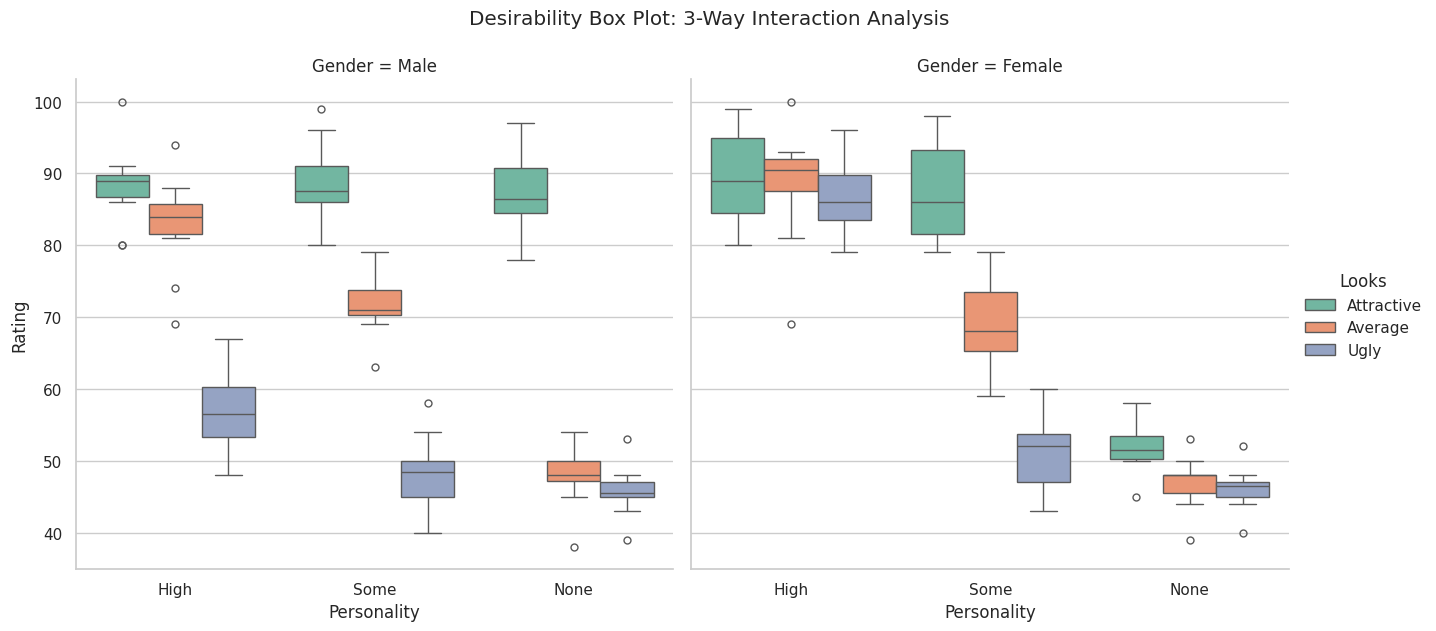

--- ASSUMPTION TESTS ---
Shapiro-Wilk Normality: p = 0.00
Levene's Homogeneity: p = 0.38


In [7]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.formula.api import ols
from scipy.stats import shapiro, levene

data = {
    'Gender': ['Male']*10 + ['Female']*10,
    'att_high': [86, 91, 89, 89, 80, 80, 89, 100, 90, 89, 89, 84, 99, 86, 89, 80, 82, 97, 95, 95],
    'av_high': [84, 83, 88, 69, 81, 84, 85, 94, 74, 86, 91, 90, 100, 89, 87, 81, 92, 69, 92, 93],
    'ug_high': [67, 53, 48, 58, 57, 51, 61, 56, 54, 63, 93, 85, 89, 83, 80, 79, 85, 87, 90, 96],
    'att_some': [88, 83, 99, 86, 88, 96, 87, 86, 92, 80, 88, 95, 80, 86, 83, 86, 81, 95, 98, 79],
    'av_some': [69, 74, 70, 77, 71, 63, 79, 71, 71, 73, 65, 70, 79, 74, 74, 59, 66, 72, 64, 66],
    'ug_some': [50, 48, 48, 40, 50, 42, 44, 54, 58, 49, 54, 60, 53, 58, 43, 47, 47, 51, 53, 46],
    'att_none': [97, 86, 90, 87, 82, 92, 86, 84, 78, 91, 55, 50, 51, 52, 58, 51, 50, 45, 54, 52],
    'av_none': [48, 50, 45, 47, 50, 48, 50, 54, 38, 48, 48, 44, 48, 48, 50, 47, 45, 48, 53, 39],
    'ug_none': [47, 46, 48, 53, 45, 43, 45, 47, 45, 39, 52, 45, 44, 47, 48, 40, 47, 46, 45, 47]
}

df = pd.DataFrame(data)
df['Subject'] = range(1, 21)
df_long = pd.melt(df, id_vars=['Subject', 'Gender'], var_name='Cond', value_name='Rating')
df_long['Looks'] = df_long['Cond'].apply(lambda x: 'Attractive' if 'att' in x else ('Average' if 'av' in x else 'Ugly'))
df_long['Personality'] = df_long['Cond'].apply(lambda x: 'High' if 'high' in x else ('Some' if 'some' in x else 'None'))

df_long['Looks'] = pd.Categorical(df_long['Looks'], categories=['Attractive', 'Average', 'Ugly'], ordered=True)
df_long['Personality'] = pd.Categorical(df_long['Personality'], categories=['High', 'Some', 'None'], ordered=True)

# 1. ANOVA Computations
model = ols('Rating ~ C(Gender) * C(Looks) * C(Personality)', data=df_long).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
print("--- ANOVA TABLE (alpha = 0.05, 2 Decimals) ---")
print(anova_table.round(2))
print("\n" + "="*50 + "\n")

# 2. Mean Ratings Table
print("--- MEAN RATINGS ---")
means = df_long.groupby(['Gender', 'Looks', 'Personality'], observed=True)['Rating'].mean().unstack()
print(means.round(2))

# Box Plot
sns.set_theme(style="whitegrid")
g = sns.catplot(
    data=df_long, x="Personality", y="Rating", hue="Looks", col="Gender",
    kind="box", palette="Set2", height=6, aspect=1.1,
    order=['High', 'Some', 'None'], hue_order=['Attractive', 'Average', 'Ugly']
)
g.fig.suptitle('Desirability Box Plot: 3-Way Interaction Analysis', y=1.05)
plt.show()

# 4. Assumption Tests
print("--- ASSUMPTION TESTS ---")
_, p_norm = shapiro(df_long['Rating'])
print(f"Shapiro-Wilk Normality: p = {p_norm:.2f}")

m_r = df_long[df_long['Gender']=='Male']['Rating']
f_r = df_long[df_long['Gender']=='Female']['Rating']
_, p_lev = levene(m_r, f_r)
print(f"Levene's Homogeneity: p = {p_lev:.2f}")